In [ ]:
import pandas as pd
import numpy as np

In [ ]:
DATA_URL = 'https://dano.hse.ru/mirror/pubs/share/987942868.csv'

In [ ]:
source_df = pd.read_csv(DATA_URL)
df = source_df.copy(deep=True)
df

,customer_id,age,gender_cd,region_size,foreign_flg,entrepreneur_flg,auto_flg,traveler_flg,partnership_flg,child_amt,...,state_talk_time_sec,wo_hit_status_result_desc,wo_hit_status_reason_desc,employee_id,emp_age,emp_gender_cd,emp_children_cnt,emp_work_months_cnt,emp_citizenship_country_cd,emp_marital_status_cd
0,422206773,58.0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,67.0,"Дозвон, Отказ",Перезвонит самостоятельно позднее,142052.0,30,W,NaN,1,NaN,NaN
1,348648289,44.0,M,rural,0.0,0.0,0.0,0.0,1.0,1.0,...,151.0,"Дозвон, Отказ",Другое,7004.0,36,W,NaN,2,RUS,NaN
2,345496995,23.0,F,town,0.0,0.0,1.0,0.0,1.0,0.0,...,68.0,"Дозвон, Успешно",Назначена встреча,80760.0,52,W,NaN,6,NaN,NaN
3,182783192,34.0,M,town,0.0,0.0,0.0,0.0,0.0,0.0,...,738.0,"Дозвон, Успешно",Обещал утилизироваться самостоятельно,158672.0,22,NaN,NaN,8,NaN,NaN
4,138498254,30.0,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.0,"Дозвон, Отказ",Переведен в банк,14462.0,51,W,NaN,7,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18686,365712573,49.0,F,urban,0.0,1.0,0.0,0.0,1.0,3.0,...,101.0,"Дозвон, Отказ",Не устраивает одобренная сумма,191799.0,47,W,NaN,2,NaN,NaN
18687,305526568,58.0,F,msk,0.0,0.0,0.0,0.0,0.0,0.0,...,75.0,"Дозвон, Отказ",Кредитная карта не нужна,265923.0,53,W,NaN,6,NaN,NaN
18688,77876991,47.0,M,urban,0.0,1.0,1.0,1.0,1.0,1.0,...,59.0,"Дозвон, Отказ",Кредит уже не нужен,215719.0,29,M,NaN,4,NaN,NaN
18689,321508947,41.0,M,town,0.0,0.0,1.0,0.0,1.0,1.0,...,NaN,"Дозвон, Отказ",Вопросы по оплаченному полису,97765.0,39,W,NaN,0,NaN,NaN


# EDA

## common data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18691 entries, 0 to 18690
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 18691 non-null  int64  
 1   age                         18509 non-null  object 
 2   gender_cd                   18433 non-null  object 
 3   region_size                 11402 non-null  object 
 4   foreign_flg                 11402 non-null  float64
 5   entrepreneur_flg            11402 non-null  float64
 6   auto_flg                    11402 non-null  float64
 7   traveler_flg                11402 non-null  float64
 8   partnership_flg             11402 non-null  float64
 9   child_amt                   11402 non-null  float64
 10  realty_type                 11402 non-null  object 
 11  segment_cd                  11402 non-null  object 
 12  bundle_nm                   4703 non-null   object 
 13  confirmed_income            140

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,18691.0,3.166681e+08,1.488096e+08,14236.0,1.828957e+08,343686510.0,4.334274e+08,6.499757e+08
foreign_flg,11402.0,9.647430e-03,9.775068e-02,0.0,0.000000e+00,0.0,0.000000e+00,1.000000e+00
entrepreneur_flg,11402.0,1.383091e-01,3.452392e-01,0.0,0.000000e+00,0.0,0.000000e+00,1.000000e+00
auto_flg,11402.0,5.016664e-01,5.000192e-01,0.0,0.000000e+00,1.0,1.000000e+00,1.000000e+00
traveler_flg,11402.0,1.955797e-02,1.384816e-01,0.0,0.000000e+00,0.0,0.000000e+00,1.000000e+00
partnership_flg,11402.0,7.904754e-01,4.069872e-01,0.0,1.000000e+00,1.0,1.000000e+00,1.000000e+00
child_amt,11402.0,3.777407e-01,6.642255e-01,0.0,0.000000e+00,0.0,1.000000e+00,7.000000e+00
confirmed_income,1407.0,1.537048e+04,1.032459e+04,7823.5,9.871190e+03,12823.5,1.701333e+04,1.471284e+05
predicted_income,4087.0,7.203861e+06,4.594889e+08,-6274.5,1.282350e+04,14921.2,1.790127e+04,2.937498e+10
state_talk_time_sec,18543.0,8.635011e+01,1.270116e+02,0.0,2.400000e+01,46.0,9.900000e+01,2.671000e+03


In [ ]:
# посотрим насколько осмысленны незаполненные данные и можно ли от них отказаться
df[df['segment_cd'].isna()]
# кажется есть смысл с ними повозиться, по крафней мере есть пол и возраст клиента и кое-что о сотруднике

,customer_id,age,gender_cd,region_size,foreign_flg,entrepreneur_flg,auto_flg,traveler_flg,partnership_flg,child_amt,...,state_talk_time_sec,wo_hit_status_result_desc,wo_hit_status_reason_desc,employee_id,emp_age,emp_gender_cd,emp_children_cnt,emp_work_months_cnt,emp_citizenship_country_cd,emp_marital_status_cd
0,422206773,58.0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,67.0,"Дозвон, Отказ",Перезвонит самостоятельно позднее,142052.0,30,W,NaN,1,NaN,NaN
4,138498254,30.0,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.0,"Дозвон, Отказ",Переведен в банк,14462.0,51,W,NaN,7,NaN,NaN
7,37214043,55.0,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.0,"Дозвон, Отказ",Другое (нестандартная ситуация),14462.0,51,W,NaN,7,NaN,NaN
11,400159317,27.0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35.0,"Дозвон, Отказ",Кредитная карта не нужна,195977.0,23,NaN,NaN,10,NaN,NaN
14,483808847,34.0,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.0,"Дозвон, Отказ",Отказ прослушать предложение,40200.0,46,W,NaN,6,RUS,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18673,591308610,23.0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,628.0,"Дозвон, Успешно",Успешно,266046.0,21,M,NaN,0,RUS,UNM
18679,428174801,19.0,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90.0,"Дозвон, Отказ",Пользуется картой другого банка,191315.0,22,W,NaN,4,NaN,NaN
18682,300003956,34.0,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,121.0,"Дозвон, Успешно",Назначена встреча,155872.0,22,NaN,NaN,11,NaN,NaN
18685,189614349,35.0,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,69.0,"Дозвон, Отказ",Не нужен продукт,223598.0,56,W,NaN,7,RUS,UNM


##  Клиент

### Age

In [ ]:
df['age'] = pd.to_numeric(df['age'].str.replace(',', '.'), errors='coerce')
df['age'].isna().sum()

np.int64(182)

In [ ]:
print(df['age'].median())
df['age'] = df['age'].fillna(df['age'].median())

37.0


<Axes: >

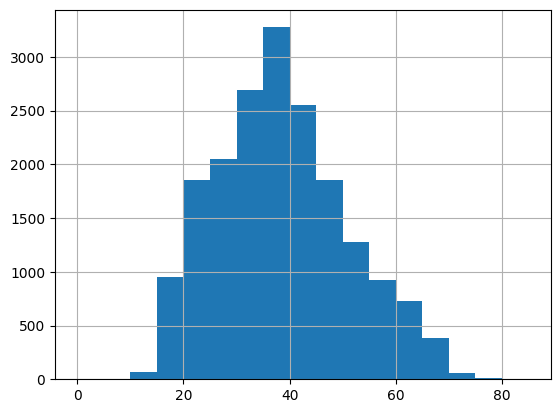

In [ ]:
df.age.hist(bins=range(0, int(df.age.max())+1, 5))

### Gender

In [ ]:
print(df['gender_cd'].isna().sum())
df['gender_cd'].value_counts()

258


,count
gender_cd,
M,9881
F,8552


In [ ]:
#df['gender_cd'] = df['gender_cd'].fillna(df['gender_cd'].mode()[0])
df['gender_cd'] = df['gender_cd'].fillna('U') # Unknown
# чтобы избежать намеренных искажений со стороны организаторов просто удалим эти строки

### Регион

In [ ]:
df['region_size'].value_counts(dropna=False)

,count
region_size,
NaN,7289
town,6054
urban,2661
msk,1559
rural,1128


In [ ]:
df['region_size'] = df['region_size'].fillna('unknown')

### Флаги (foreign_flg', 'entrepreneur_flg', 'auto_flg', 'traveler_flg', 'partnership_flg'), здесь же посмотрим подписку bundle_nm

In [ ]:
df[['foreign_flg', 'entrepreneur_flg', 'auto_flg', 'traveler_flg', 'partnership_flg']].apply(lambda x: x.value_counts(dropna=False))

,foreign_flg,entrepreneur_flg,auto_flg,traveler_flg,partnership_flg
0.0,11292,9825,5682,11179,2389
1.0,110,1577,5720,223,9013
NaN,7289,7289,7289,7289,7289


In [ ]:
# Для флагов с явным большинством заполняем самым частым значением
df['foreign_flg'] = df['foreign_flg'].fillna(0)
df['traveler_flg'] = df['traveler_flg'].fillna(0)

# Для остальных флагов добавляем новое значение2. - неизвестно
df['entrepreneur_flg'] = df['entrepreneur_flg'].fillna(2.)
df['auto_flg'] = df['auto_flg'].fillna(2.)
df['partnership_flg'] = df['partnership_flg'].fillna(2.)

In [ ]:
display(df['bundle_nm'].value_counts())
# отнесем отсутствующие и неизвестные в одну группу
df['partnership_flg'] = df['partnership_flg'].fillna('NO_AND_UNK')

,count
bundle_nm,
Pro,4406
Premium,296
XXX,1


### Дети

In [ ]:
df['child_amt'].value_counts(dropna=False)

,count
child_amt,
0.0,8029
NaN,7289
1.0,2633
2.0,580
3.0,136
4.0,16
5.0,7
7.0,1


In [ ]:
# заполним по-среднему
# наверное можно придумать более хитрый способ, например, с учетом наличия партнера
# но в первом приближении оставим так
print(df['child_amt'].mean())
df['child_amt'] = df['child_amt'].fillna(df['child_amt'].mean())

0.37774074723732676


### Тип жилья

In [ ]:
df['realty_type'].value_counts(dropna=False)

,count
realty_type,
NaN,7289
Квартира,5731
Нет своего жилья,5445
Жилой дом,130
Комната,96


In [ ]:
df['realty_type'] = df['realty_type'].fillna('Неизвестно')

### Доходы: segment_cd, confirmed_income, predicted_income

In [ ]:
# segment_cd, confirmed_income, predicted_income
# df['segment_cd'].value_counts(dropna=False)
# 45 разновидностей половина незаполнена.


In [ ]:
df['confirmed_income'].isna().sum(), df['predicted_income'].isna().sum()

(np.int64(17284), np.int64(14604))

теоретически восстановить доход можно из поля сегмент, в первом приближении пропустим. Если останется время и сохранится необходимость - к вопросу о восстановлении дохода можно будет вернуться позже, пока восстановим из сегмента относительный доход и абсолютный номер сегмента.


In [ ]:
df['inc_relative'] = pd.to_numeric(df['segment_cd'].str.extract(r'_(\d{2})')[0], errors='coerce').fillna(0).astype(int)
df['seg_id'] = pd.to_numeric(df['segment_cd'].str.extract(r'\((\d+)\)')[0], errors='coerce').fillna(0).astype(int)

### причина звонка functional_cd'

In [ ]:
df['functional_cd'].value_counts(dropna=False)

,count
functional_cd,
Preapprove,9025
Afterfilling,2352
Utilization,1717
Cold,1537
Upsell,1342
Meeting,1064
Agreement,547
Incoming,361
Downsell,229


### Время и дата звонка 'finish_dttm', 'state_talk_time_sec'

148 86.3501051609772


<Axes: >

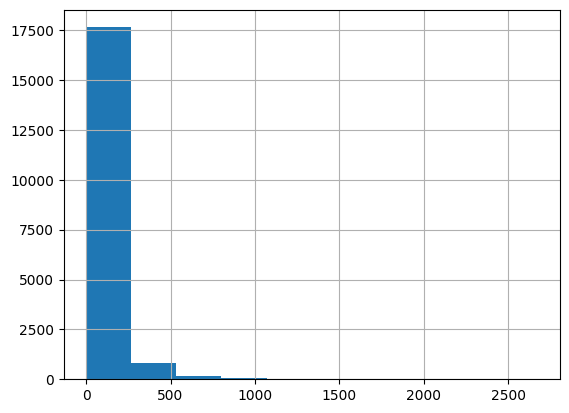

In [ ]:
print(df['state_talk_time_sec'].isna().sum(),df['state_talk_time_sec'].mean())
df['state_talk_time_sec'] = df['state_talk_time_sec'].fillna(df['state_talk_time_sec'].mean())
df['state_talk_time_sec'].hist()

In [ ]:
#'finish_dttm', 'state_talk_time_sec'
print(df['finish_dttm'].isna().sum())

0


In [ ]:
df['finish_dttm'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 18691 entries, 0 to 18690
Series name: finish_dttm
Non-Null Count  Dtype 
--------------  ----- 
18691 non-null  object
dtypes: object(1)
memory usage: 146.2+ KB


In [ ]:
df['datetime'] = pd.to_datetime(df['finish_dttm'])
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6])
# потенциально можно еще сделать признаков, в первом приближении ограничимся этими

<Axes: >

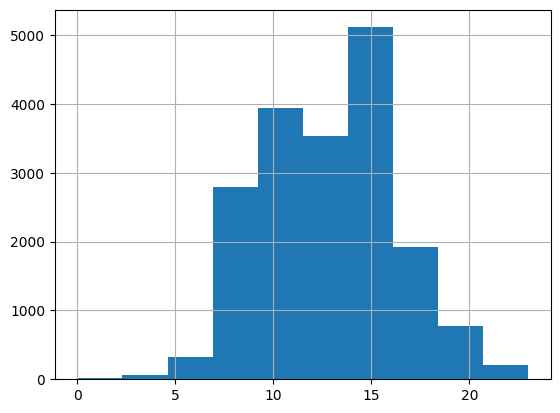

In [ ]:
df['hour'].hist()

<Axes: >

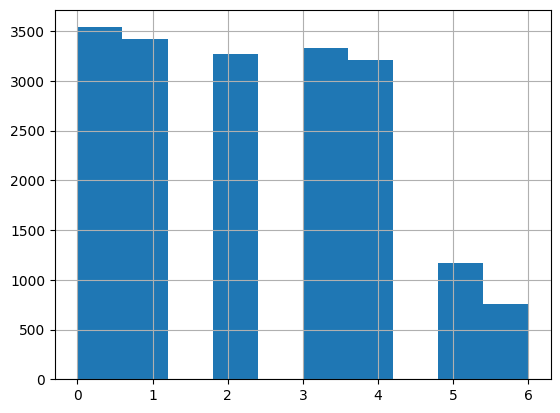

In [ ]:
df['day_of_week'].hist()

In [ ]:
df['is_weekend'].value_counts()

,count
is_weekend,
False,16766
True,1925


### Результаты контакта

In [ ]:
# 'wo_hit_status_result_desc', 'wo_hit_status_reason_desc'
df['wo_hit_status_result_desc'].value_counts('dropna=False')

,proportion
wo_hit_status_result_desc,
"Дозвон, Отказ",0.870686
"Дозвон, Успешно",0.129314


In [ ]:
df['wo_hit_status_reason_desc'].value_counts('dropna=False')

,proportion
wo_hit_status_reason_desc,
Кредитная карта не нужна,0.207052
Отказ прослушать предложение,0.138730
Другое,0.104275
Кредит уже не нужен,0.088010
Назначена встреча,0.068589
...,...
Собственники дети,0.000054
Другое,0.000054
Готов использовать карту. Осуществлен перевыпуск,0.000054


## Оператор

<Axes: >

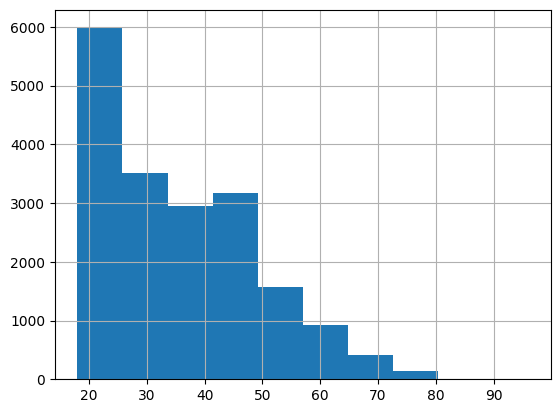

In [ ]:
df['emp_age'].hist()

In [ ]:
display(df['emp_gender_cd'].value_counts())
# запоним женщинами
df['emp_gender_cd'] = df['emp_gender_cd'].fillna('W')

,count
emp_gender_cd,
W,13483
M,3028


In [ ]:
df['emp_children_cnt'].value_coPreapproveunts() # слишком мало данных

,count
emp_children_cnt,
0.0,45
3.0,29
1.0,12


<Axes: >

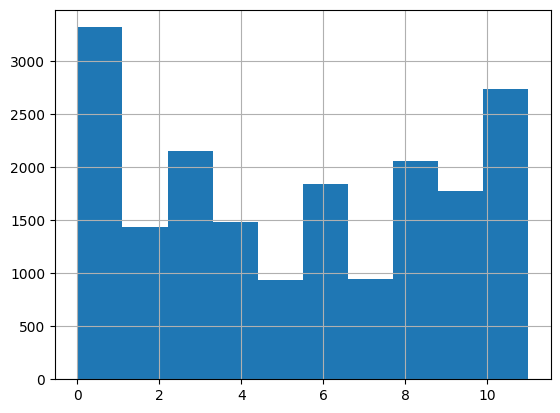

In [ ]:
df['emp_work_months_cnt'].hist()

In [ ]:
# практичесмки ничего не дает это поле
df['emp_citizenship_country_cd'].value_counts()

,count
emp_citizenship_country_cd,
RUS,6203
BEL,1


In [ ]:
# тоже  мало данных навскидку
df['emp_marital_status_cd'].value_counts()

,count
emp_marital_status_cd,
UNM,3692
MAR,145
DIV,29


## Гипотезы

### посмотрим корреляции в числовых данных

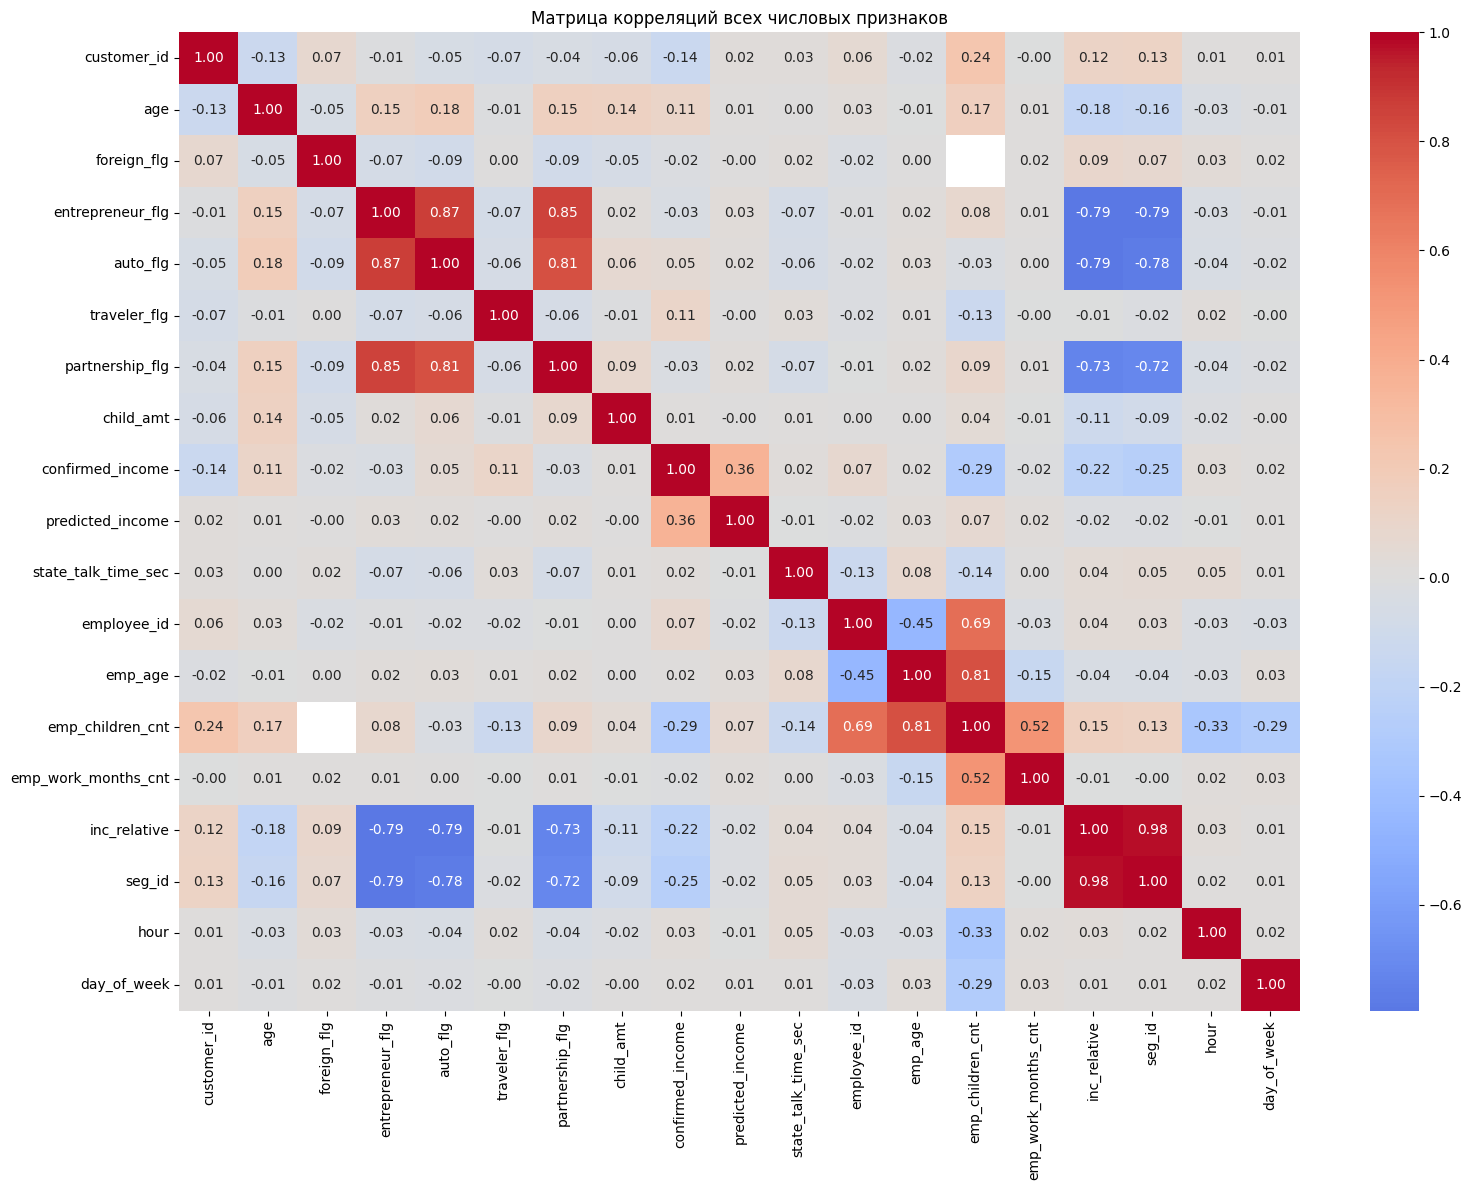

In [ ]:
# Некоторые пересечения смысла иметь не будут но от чего-нибудь нужно оттолкнуться

numeric_df = df.select_dtypes(include=['number'])

# Строим тепловую карту корреляций
plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

# самой интересной колонкой выглядит число детей у сторудника

Гипотеза 1.
~~На графике наблюдаем корреляцию времени работы сотрудников с наличием детей. Кажется можно попробовать синхронизировать расписание родителей-операторов и родителей-клиентов, то есть звонить родителям-клиентам во время работы родителей-операторов. Смысл в том, что когда у одних родителей появляется время поработать, у других может найтись время поговорить. Гарантий никаких.~~
Решил отказаться от этой гипотезы - встречной корреляции у клиентов-родителей не наблюдается. Сводить родителей-операторов и родителей-клиентов смысл может быть есть, но обоснование нужно искать другое.

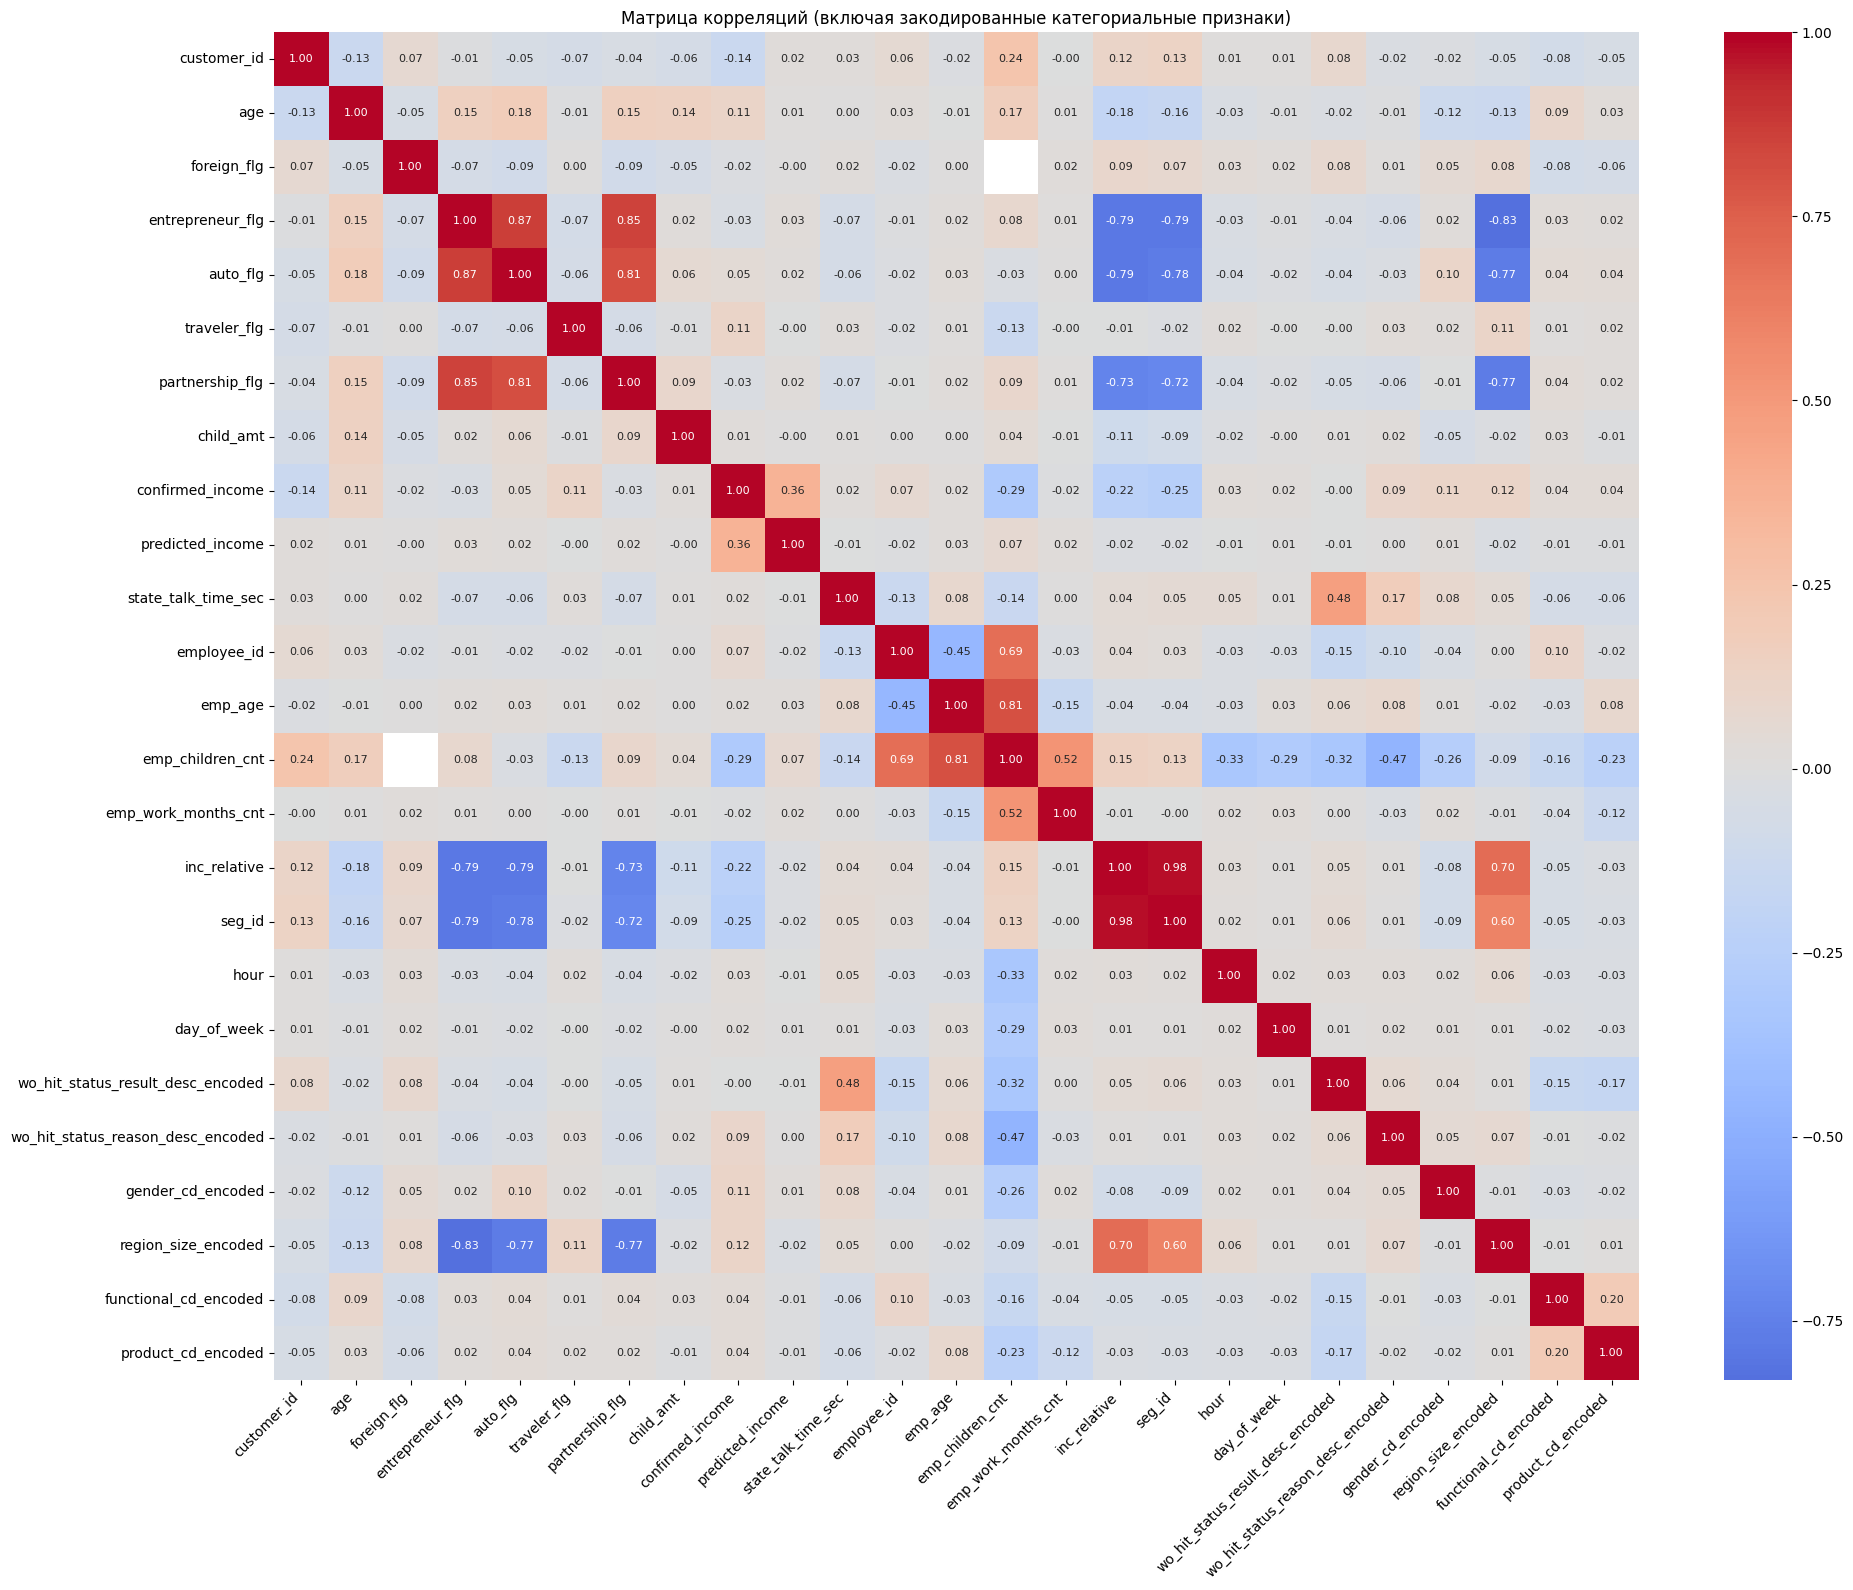

In [ ]:
# В каком-нибудь виде добавим категории

correlation_df = df.copy()

# Кодируем категориальные переменные в числа
categorical_columns = ['wo_hit_status_result_desc', 'wo_hit_status_reason_desc',
                      'gender_cd', 'region_size', 'functional_cd', 'product_cd']

for col in categorical_columns:
    correlation_df[col + '_encoded'] = correlation_df[col].factorize()[0]

# Теперь строим матрицу корреляций со всеми признаками
plt.figure(figsize=(20, 16))
numeric_cols = correlation_df.select_dtypes(include=['number']).columns
sns.heatmap(correlation_df[numeric_cols].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', annot_kws={'size': 8})
plt.title('Матрица корреляций (включая закодированные категориальные признаки)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ничего нового сходу не увидел

### сегментируем клиентов и операторов по полу и возрасту

и посмотрим кому с кем приятно беседовать

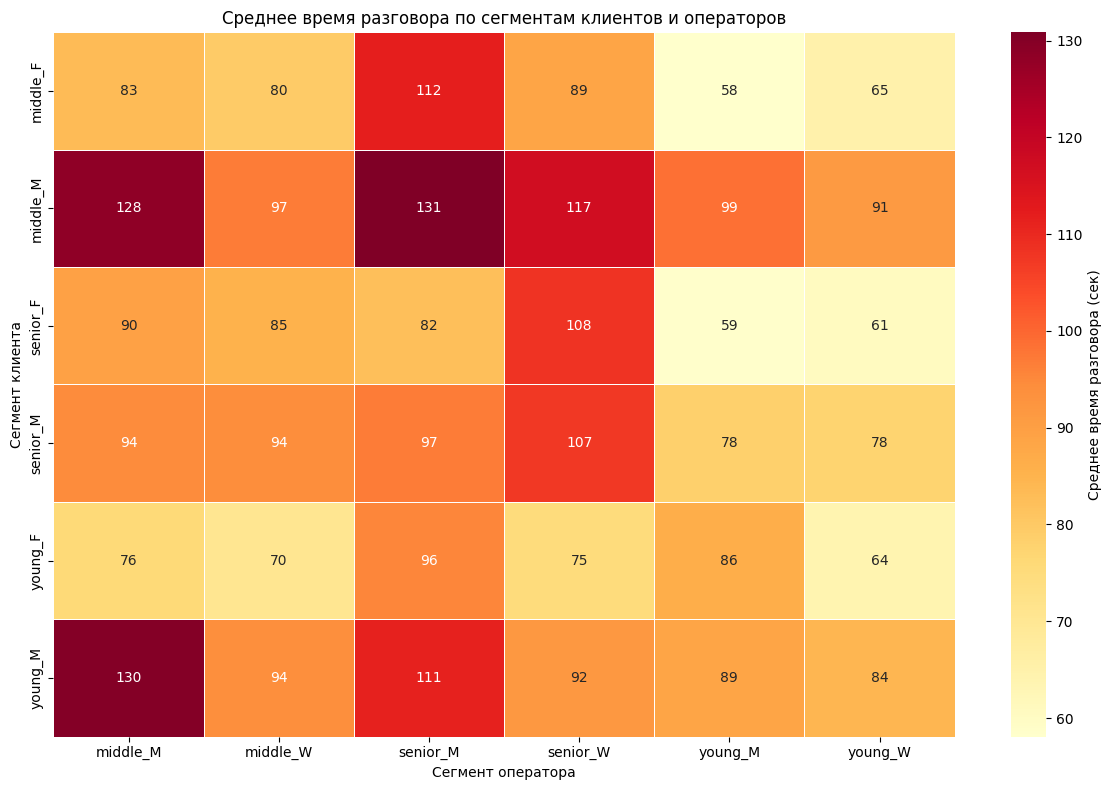

Количество наблюдений в каждом сегменте:
emp_segment     middle_M  middle_W  senior_M  senior_W  young_M  young_W
client_segment                                                          
middle_F             164      1810        95       675      458     1490
middle_M             208      2163       122       842      630     1720
senior_F              68       698        16       275      222      621
senior_M              57       556        17       239      150      468
young_F               74       715        25       301      230      615
young_M              102      1152        33       421      357      902


In [ ]:
# Создаем сегменты клиентов и сотрудников
df['client_segment'] = df['age'].apply(lambda x: 'young' if x < 30 else 'middle' if x < 50 else 'senior') + '_' + df['gender_cd']
df['emp_segment'] = df['emp_age'].apply(lambda x: 'young' if x < 30 else 'middle' if x < 50 else 'senior') + '_' + df['emp_gender_cd']

# Строим сводную таблицу с средним временем разговора
pivot_table = df.pivot_table(
    values='state_talk_time_sec',
    index='client_segment',
    columns='emp_segment',
    aggfunc='mean',
    fill_value=0
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Среднее время разговора (сек)'})
plt.title('Среднее время разговора по сегментам клиентов и операторов')
plt.xlabel('Сегмент оператора')
plt.ylabel('Сегмент клиента')
plt.tight_layout()
plt.show()


Гипотеза 2. Разные гендерно-возрастные группы пользователей по-разному взаимодействуют между собой.  На карте видим, например, что молодые женщины-операторы разговаривают с мужчинами значительно дольше чем с женщинами. Также видно, что молодые клиенты-женщины дольше разговаривают с операторами мужчинами. Гипотезу можно сформулировать так: учет пола и возраста клиента

Продуктовая гипотеза (Строгая формулировка)

Гипотеза 2: Если внедрить систему роутинга звонков, которая будет учитывать гендерно-возрастные характеристики клиента и оператора (например, назначать молодых клиентов-женщин на операторов-мужчин, а клиентов-мужчин — на молодых операторов-женщин), то средняя продолжительность полезного контакта (state_talk_time_sec) увеличится на X%, а конверсия в целевое действие — на Y%.

Ожидаемый механизм: Создание более комфортной психологической атмосферы и быстрого установления раппорта за счет неосознанного предпочтения в коммуникации между определенными гендерно-возрастными группами, что приводит к более длительному и продуктивному диалогу.
Как это проверить на данных (Критерии проверки):

    Подтверждение паттерна: На уже существующих данных необходимо статистически подтвердить, что выявленные закономерности (например, более долгие разговоры между молодыми операторами-женщинами и клиентами-мужчинами) являются статистически значимыми, а не случайными.

    A/B-тест: Разделить входящие лиды от молодых клиентов на две группы:

        Контрольная группа: Распределение операторов по стандартному алгоритму (например, по очереди).

        Пилотная группа: Целевое распределение на основе подтвержденных гендерно-возрастных паттернов.

    Ключевые метрики: Сравнить между группами среднее время разговора и конверсию в продажу/одобренную заявку.

Формулировка для слайда презентации:

    Гипотеза 2: Повышение эффективности коммуникации за счет гендерно-возрастного роутинга

        Предложение: Внедрить алгоритм распределения звонков, который назначает клиентов операторам на основе выявленных паттернов успешной коммуникации между гендерно-возрастными группами.

        Ожидаемый эффект: Рост длительности осмысленного контакта и конверсии за счет улучшения качества взаимодействия на уровне "клиент-оператор".

        Критерий проверки: A/B-тест, измеряющий разницу в state_talk_time_sec и конверсии между контрольной и пилотной группами с целевым распределением.

Доля Т-банка на рыке кредитов - примерно 7% (примерно 2.4 трлн из 35), сообщил дипсик, проверить не успел.